Nombre: Emilio Rico Hernández
Clase: 6
Challenge: ¿Los datos realmente dicen eso?
Fecha: 2026-09-25

# Challenge 6 — ¿Los datos realmente dicen eso?

Uso `dataset_limpio.csv`, el resultado del Challenge 4 (1,800 clientes únicos). En el Challenge 2 vi que los clientes que abandonan el servicio parecían menos satisfechos. La pregunta ahora es si esa diferencia es estadísticamente sólida o pudo ser casualidad.

- **Grupo A:** clientes que abandonaron (`churn = 1`).
- **Grupo B:** clientes que se quedaron (`churn = 0`).
- **Variable:** `satisfaccion`, de 0 a 10. Los clientes sin dato de satisfacción se excluyen porque no contestaron.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

df = pd.read_csv("dataset_limpio.csv")
grupo_a = df.loc[df["churn"] == 1, "satisfaccion"].dropna()   # abandonan
grupo_b = df.loc[df["churn"] == 0, "satisfaccion"].dropna()   # se quedan
print("Clientes:", len(df), "| con satisfacción en A:", len(grupo_a), "| en B:", len(grupo_b))

Clientes: 1800 | con satisfacción en A: 144 | en B: 1611


## Paso 1 — Estadística descriptiva

In [2]:
tabla = df.groupby("churn")["satisfaccion"].agg(["count", "mean", "median", "std", "sem"])   # sem = error estándar
tabla["ic95_inf"] = tabla["mean"] - 1.96 * tabla["sem"]
tabla["ic95_sup"] = tabla["mean"] + 1.96 * tabla["sem"]
tabla.round(3)

,count,mean,median,std,sem,ic95_inf,ic95_sup
churn,,,,,,,
0,1611,8.303,8.4,1.132,0.028,8.248,8.358
1,144,7.477,7.5,1.188,0.099,7.283,7.671


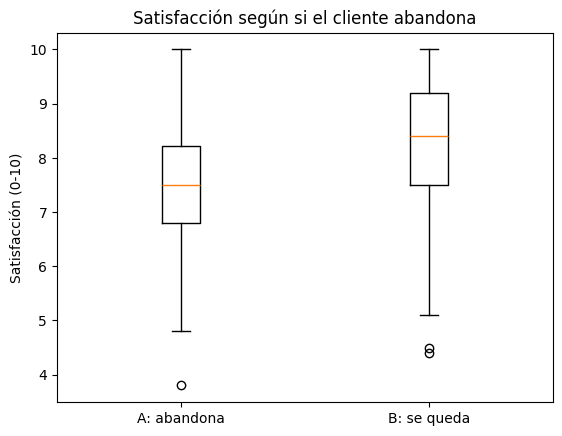

In [3]:
plt.boxplot([grupo_a, grupo_b])
plt.xticks([1, 2], ["A: abandona", "B: se queda"])
plt.ylabel("Satisfacción (0-10)")
plt.title("Satisfacción según si el cliente abandona")
plt.show()

Quedan 1,755 clientes con satisfacción (144 en A y 1,611 en B); los 45 sin respuesta se excluyen. A simple vista los que abandonan están menos satisfechos: media de 7.48 contra 8.30 (medianas de 7.5 y 8.4), y en el diagrama de caja la caja y la mediana de A quedan más abajo. Los intervalos de confianza al 95% no se traslapan: [7.28, 7.67] para A y [8.25, 8.36] para B. El de A es más ancho (0.39 puntos contra 0.11) porque tiene muchos menos clientes, así que hay más incertidumbre sobre su media. Las desviaciones estándar son parecidas (1.19 y 1.13).

## Paso 2 — Hipótesis

- H₀: μ_A = μ_B (la satisfacción promedio es igual en los dos grupos)
- H₁: μ_A ≠ μ_B (es distinta)
- Nivel de significancia: α = 0.05

## Paso 3 — Prueba t de Welch

In [4]:
t, p = stats.ttest_ind(grupo_a, grupo_b, equal_var=False)   # Welch: no asume varianzas iguales
print(f"t = {t:.3f}")
print(f"p = {p:.3e}")

t = -8.026
p = 1.704e-13


## Paso 4 — Decisión

In [5]:
alfa = 0.05
if p < alfa:
    print("p < 0.05 -> se RECHAZA H0")
else:
    print("p >= 0.05 -> NO se rechaza H0")

p < 0.05 -> se RECHAZA H0


Con p ≈ 1.7×10⁻¹³, mucho menor que 0.05, **rechazo H₀**: hay evidencia de que la satisfacción promedio de quienes abandonan (7.48) es distinta de la de quienes se quedan (8.30). El estadístico t = -8.03 es negativo porque A tiene la media más baja, y su valor absoluto es grande. Usé Welch porque los grupos son de tamaños muy distintos (144 y 1,611) y no quise suponer que tienen la misma varianza.

## Paso 5 — Tamaño del efecto

In [6]:
dif = grupo_a.mean() - grupo_b.mean()
sp = np.sqrt(((len(grupo_a) - 1) * grupo_a.var() + (len(grupo_b) - 1) * grupo_b.var()) / (len(grupo_a) + len(grupo_b) - 2))
print("Diferencia de medias (A - B):", round(dif, 3), "puntos")
print("d de Cohen:", round(dif / sp, 3))

Diferencia de medias (A - B): -0.826 puntos
d de Cohen: -0.727


La diferencia de medias es de 0.83 puntos y la d de Cohen es de -0.73. Tomando como referencia 0.2 pequeño, 0.5 mediano y 0.8 grande, es un efecto entre mediano y grande: los que abandonan tienen una satisfacción cerca de tres cuartos de desviación estándar más baja.

**¿Una diferencia significativa también es importante en la práctica?** No necesariamente. El valor p depende mucho del tamaño de la muestra (con miles de datos, hasta diferencias mínimas salen significativas), mientras que la importancia práctica depende del tamaño del efecto y del contexto. Aquí coinciden: la diferencia es significativa y el efecto no es pequeño. Aun así, 0.83 puntos en una escala de 10 no permite predecir por sí solo quién se va, porque en el diagrama de caja los dos grupos se traslapan bastante.

## Paso 6 — Correlación (Pearson)

Elijo `sesiones_mes` (uso de la app) y `gasto_mensual`.

In [7]:
df[["sesiones_mes", "gasto_mensual"]].corr()

,sesiones_mes,gasto_mensual
sesiones_mes,1.000000,0.317141
gasto_mensual,0.317141,1.000000


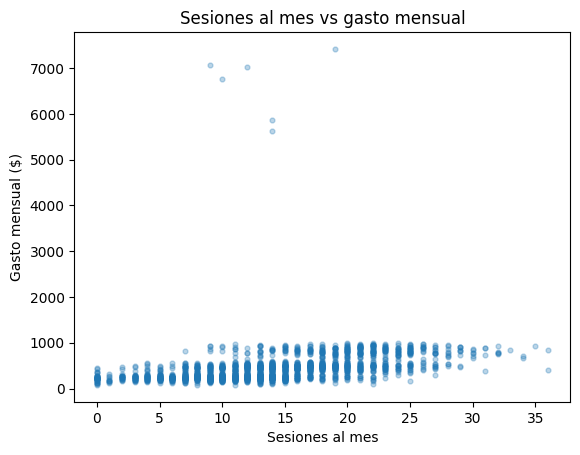

In [8]:
plt.scatter(df["sesiones_mes"], df["gasto_mensual"], alpha=0.3, s=12)
plt.xlabel("Sesiones al mes")
plt.ylabel("Gasto mensual ($)")
plt.title("Sesiones al mes vs gasto mensual")
plt.show()

In [9]:
# ¿Cambia la correlación si quito los gastos extremos que se ven en la gráfica?
sin_extremos = df[df["gasto_mensual"] < 2000]
print("Clientes sin los gastos extremos:", len(sin_extremos), "de", len(df))
print(sin_extremos[["sesiones_mes", "gasto_mensual"]].corr().round(3))

Clientes sin los gastos extremos: 1794 de 1800
               sesiones_mes  gasto_mensual
sesiones_mes          1.000          0.615
gasto_mensual         0.615          1.000


El coeficiente de Pearson es r = 0.32: la relación es **positiva** (más sesiones al mes, más gasto) y de magnitud **débil a moderada**, ya que r² ≈ 0.10, es decir, las sesiones explican linealmente cerca del 10% de la variación del gasto. En la gráfica se ven seis clientes con gastos entre unos $5,600 y $7,400, muy lejos del resto, que casi no pasa de $1,000. Como Pearson es sensible a valores así, calculé la correlación sin ellos: sube a r = 0.62 con 1,794 clientes. O sea, esos seis casos estaban "aplastando" el coeficiente; en el resto de los clientes la relación es moderada a fuerte. No los eliminé del análisis, solo quise ver cuánto pesaban.

## Preguntas de reflexión

1. **¿Existe diferencia estadísticamente significativa?** Sí. Con α = 0.05, la prueba de Welch da p ≈ 1.7×10⁻¹³, así que rechazo H₀: la satisfacción promedio de quienes abandonan (7.48) es distinta de la de quienes se quedan (8.30).

2. **¿Qué indica el valor p?** Qué tan probable sería ver una diferencia tan grande (o mayor) entre los grupos si en realidad no hubiera ninguna diferencia. Un p tan pequeño hace ese escenario muy poco compatible con los datos. No es la probabilidad de que H₀ sea cierta ni dice qué tan grande es la diferencia.

3. **¿Los intervalos de confianza son amplios o estrechos?** Estrechos en general, en una escala de 0 a 10: el de B mide 0.11 puntos de ancho (n = 1,611) y el de A 0.39 (n = 144). El de A es más ancho por tener menos clientes, pero aun así no se traslapa con el de B.

4. **¿El tamaño del efecto parece importante?** Sí, moderadamente: d = -0.73 (mediano a grande), equivalente a 0.83 puntos de 10. Es relevante para el negocio, pero no basta por sí solo para predecir quién se va.

5. **¿Qué significa la correlación encontrada?** Que sesiones al mes y gasto mensual tienen una asociación positiva (r = 0.32 con todos los clientes, débil a moderada; r = 0.62 si quito seis gastos extremos): quienes usan más la app tienden a gastar más. No significa que una cause la otra.

## Conclusión para una persona no especialista

Quise saber si los clientes que dejaron el servicio realmente estaban menos contentos que los que se quedaron, o si esa diferencia podía ser casualidad. Comparé la satisfacción (de 0 a 10) de 144 clientes que se fueron con la de 1,611 que se quedaron: los primeros calificaron en promedio 7.5 y los segundos 8.3. Con una prueba estadística comprobé que esa diferencia es demasiado grande para ser coincidencia, y su tamaño es de mediano a grande, así que no es un detalle menor. Eso no quiere decir que la insatisfacción sea la única razón por la que se van, porque los dos grupos se traslapan (hay clientes satisfechos que se fueron y poco satisfechos que se quedaron); sí es una señal de alerta útil para cuidar a quienes califican más bajo. También vi que quienes usan más la app tienden a gastar más, pero eso no prueba que usarla más haga que gasten más.